In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# 차트에 한글 깨지지 않도록 차트 폰트변경
plt.rcParams['font.family'] = 'Malgun Gothic'
# 차트에 "-"문자 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 준비

In [5]:
scores = [
70, 75, 83, 68, 74, 78, 71, 85, 76, 69,
73, 80, 77, 72, 68, 82, 75, 70, 79, 74,
67, 81, 76, 73, 78, 69, 84, 71, 75, 80,
72, 77, 68, 74, 82, 79, 70, 76, 85, 73,
69, 81, 75, 78, 72, 67, 80, 74, 77, 71,
83, 76, 70, 79, 73, 68, 82, 75, 71, 78,
74, 80, 69, 77, 72, 81, 76, 70, 84, 73,
75, 79, 68, 82, 74,115, 120, 125]

scores_np = np.array(scores)
scores_series = pd.Series(scores)

print(scores_np)
print(scores_series)

[ 70  75  83  68  74  78  71  85  76  69  73  80  77  72  68  82  75  70
  79  74  67  81  76  73  78  69  84  71  75  80  72  77  68  74  82  79
  70  76  85  73  69  81  75  78  72  67  80  74  77  71  83  76  70  79
  73  68  82  75  71  78  74  80  69  77  72  81  76  70  84  73  75  79
  68  82  74 115 120 125]
0      70
1      75
2      83
3      68
4      74
     ... 
73     82
74     74
75    115
76    120
77    125
Length: 78, dtype: int64


## 2. IQR 방법

In [7]:
# 중앙값
median = scores_series.median()

# Q1, Q3
Q1 = scores_series.quantile(0.25)
Q3 = scores_series.quantile(0.75)

# IQR
IQR = Q3 - Q1

# 이상치 기준
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 최소값, 최대값
minimum = scores_series.min()
maximum = scores_series.max()

print("중앙값:", median)
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("하한:", lower)
print("상한:", upper)
print("최소값:", minimum)
print("최대값:", maximum)

# 이상치
outliers_iqr = scores_series[
    (scores_series < lower) | (scores_series > upper)
]

print("IQR 이상치:", outliers_iqr.values)

중앙값: 75.0
Q1: 71.25
Q3: 79.75
IQR: 8.5
하한: 58.5
상한: 92.5
최소값: 67
최대값: 125
IQR 이상치: [115 120 125]


## 3. 박스플롯

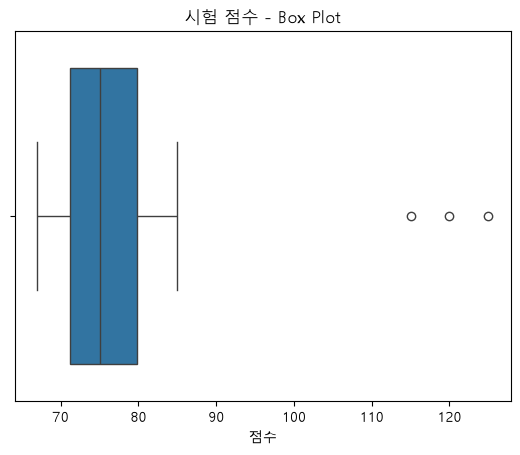

In [8]:
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.boxplot(x=scores_series, ax=axes1)

axes1.set_title("시험 점수 - Box Plot")
axes1.set_xlabel("점수")

plt.show()

## 4. Z-score 방법

In [9]:
# 평균
mean = scores_np.mean()

# 분산
variance = scores_np.var()

# 표준편차
std = scores_np.std()

print("평균:", round(mean, 2))
print("분산:", round(variance, 2))
print("표준편차:", round(std, 2))


# Z-score 계산
z_scores = (scores_np - mean) / std

print("Z-score:")
print(np.round(z_scores, 2))

평균: 76.95
분산: 97.59
표준편차: 9.88
Z-score:
[-0.7  -0.2   0.61 -0.91 -0.3   0.11 -0.6   0.82 -0.1  -0.8  -0.4   0.31
  0.01 -0.5  -0.91  0.51 -0.2  -0.7   0.21 -0.3  -1.01  0.41 -0.1  -0.4
  0.11 -0.8   0.71 -0.6  -0.2   0.31 -0.5   0.01 -0.91 -0.3   0.51  0.21
 -0.7  -0.1   0.82 -0.4  -0.8   0.41 -0.2   0.11 -0.5  -1.01  0.31 -0.3
  0.01 -0.6   0.61 -0.1  -0.7   0.21 -0.4  -0.91  0.51 -0.2  -0.6   0.11
 -0.3   0.31 -0.8   0.01 -0.5   0.41 -0.1  -0.7   0.71 -0.4  -0.2   0.21
 -0.91  0.51 -0.3   3.85  4.36  4.86]


## 5. Z-score 이상치 판단

In [10]:
outliers_z = scores_np[np.abs(z_scores) > 3]

print("Z-score 이상치:")
print(outliers_z)

Z-score 이상치:
[115 120 125]


## 6. 히스토그램

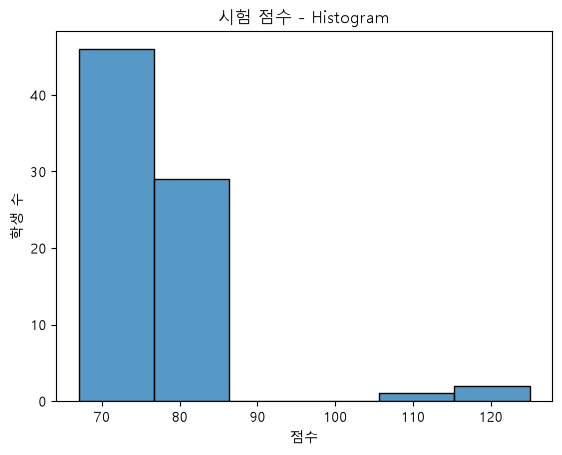

In [11]:
fig = plt.figure()

axes1 = fig.add_subplot(1, 1, 1)

sns.histplot(scores_series, bins=6, ax=axes1)

axes1.set_title("시험 점수 - Histogram")
axes1.set_xlabel("점수")
axes1.set_ylabel("학생 수")

plt.show()